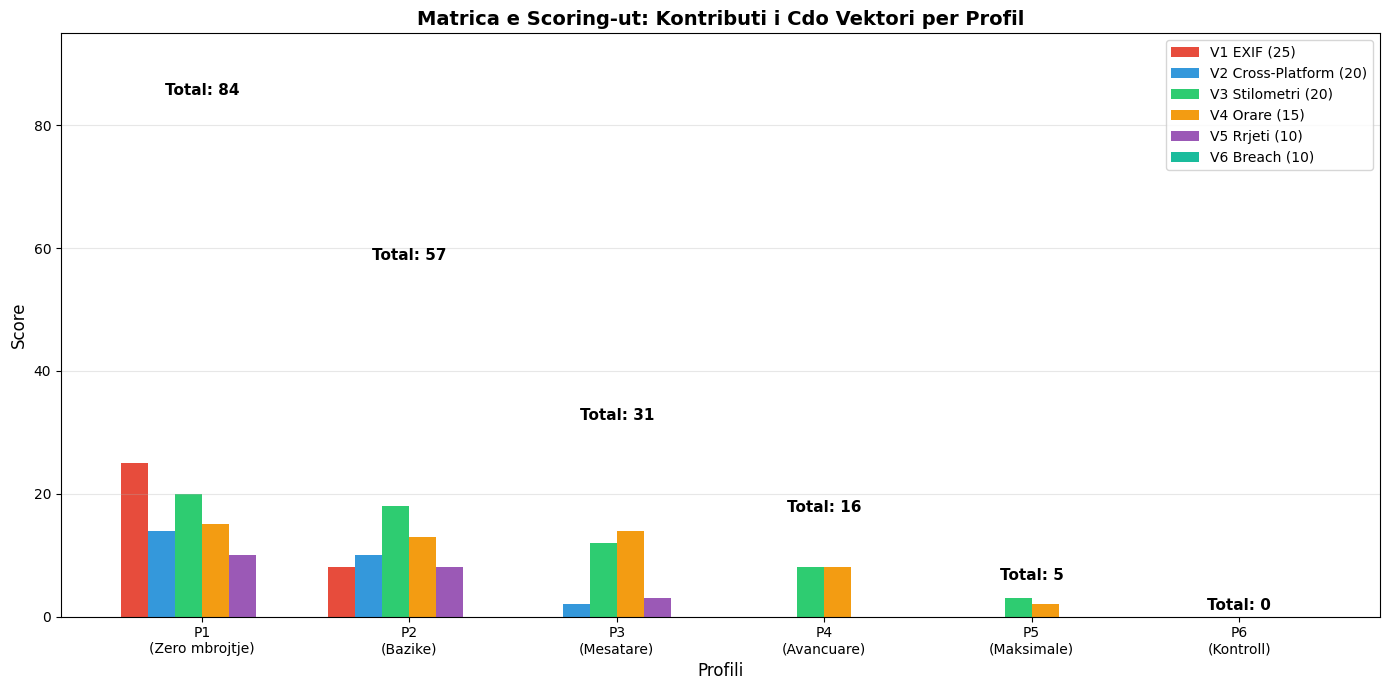

Bar chart i ruajtur


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

base = r"C:\Users\Laura Biba\Desktop\OSINT Research"

# Te dhenat
profiles = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']
v1 = [25, 8, 0, 0, 0, 0]
v2 = [14, 10, 2, 0, 0, 0]
v3 = [20, 18, 12, 8, 3, 0]
v4 = [15, 13, 14, 8, 2, 0]
v5 = [10, 8, 3, 0, 0, 0]
v6 = [0, 0, 0, 0, 0, 0]
totals = [84, 57, 31, 16, 5, 0]

x = np.arange(len(profiles))
width = 0.13

fig, ax = plt.subplots(figsize=(14, 7))

bars1 = ax.bar(x - 2.5*width, v1, width, label='V1 EXIF (25)', color='#E74C3C')
bars2 = ax.bar(x - 1.5*width, v2, width, label='V2 Cross-Platform (20)', color='#3498DB')
bars3 = ax.bar(x - 0.5*width, v3, width, label='V3 Stilometri (20)', color='#2ECC71')
bars4 = ax.bar(x + 0.5*width, v4, width, label='V4 Orare (15)', color='#F39C12')
bars5 = ax.bar(x + 1.5*width, v5, width, label='V5 Rrjeti (10)', color='#9B59B6')
bars6 = ax.bar(x + 2.5*width, v6, width, label='V6 Breach (10)', color='#1ABC9C')

# Shto totalin mbi cdo grup
for i, total in enumerate(totals):
    ax.text(i, total + 1, f'Total: {total}', ha='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Profili', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Matrica e Scoring-ut: Kontributi i Cdo Vektori per Profil', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['P1\n(Zero mbrojtje)', 'P2\n(Bazike)', 'P3\n(Mesatare)', 'P4\n(Avancuare)', 'P5\n(Maksimale)', 'P6\n(Kontroll)'])
ax.legend(loc='upper right')
ax.set_ylim(0, 95)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(base, 'figurat', 'scoring_bar_chart.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Bar chart i ruajtur")

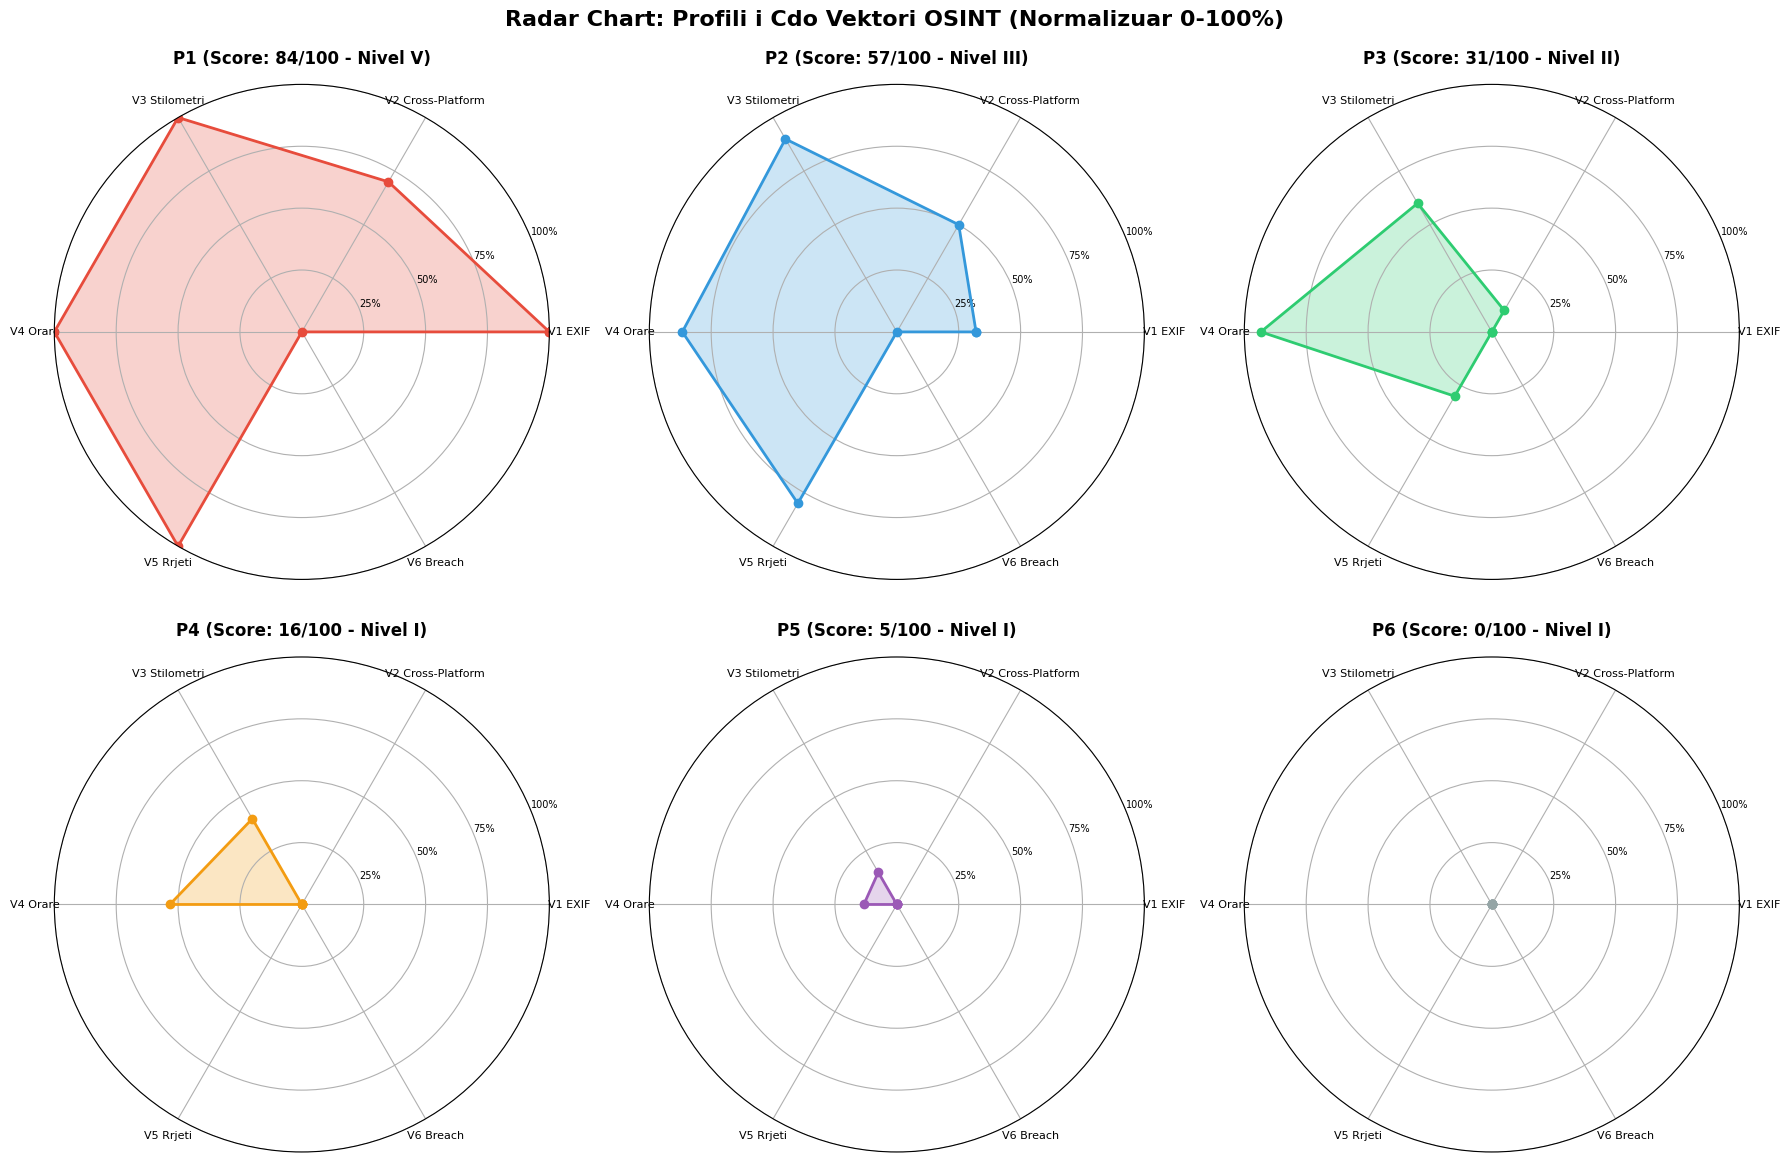

Radar chart i ruajtur


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

base = r"C:\Users\Laura Biba\Desktop\OSINT Research"

profiles = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#95A5A6']

# Vlerat e normalizuara (0-1) per radar
data = {
    'P1': [25/25, 14/20, 20/20, 15/15, 10/10, 0/10],
    'P2': [8/25, 10/20, 18/20, 13/15, 8/10, 0/10],
    'P3': [0/25, 2/20, 12/20, 14/15, 3/10, 0/10],
    'P4': [0/25, 0/20, 8/20, 8/15, 0/10, 0/10],
    'P5': [0/25, 0/20, 3/20, 2/15, 0/10, 0/10],
    'P6': [0/25, 0/20, 0/20, 0/15, 0/10, 0/10],
}

categories = ['V1 EXIF', 'V2 Cross-Platform', 'V3 Stilometri', 'V4 Orare', 'V5 Rrjeti', 'V6 Breach']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw=dict(polar=True))
fig.suptitle('Radar Chart: Profili i Cdo Vektori OSINT (Normalizuar 0-100%)', fontsize=16, fontweight='bold')

totals = [84, 57, 31, 16, 5, 0]
nivelet = ['Nivel V', 'Nivel III', 'Nivel II', 'Nivel I', 'Nivel I', 'Nivel I']

for i, profile in enumerate(profiles):
    ax = axes[i//3][i%3]
    values = data[profile]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[i])
    ax.fill(angles, values, alpha=0.25, color=colors[i])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=7)
    ax.set_title(f'{profile} (Score: {totals[i]}/100 - {nivelet[i]})', fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(os.path.join(base, 'figurat', 'scoring_radar_chart.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Radar chart i ruajtur")

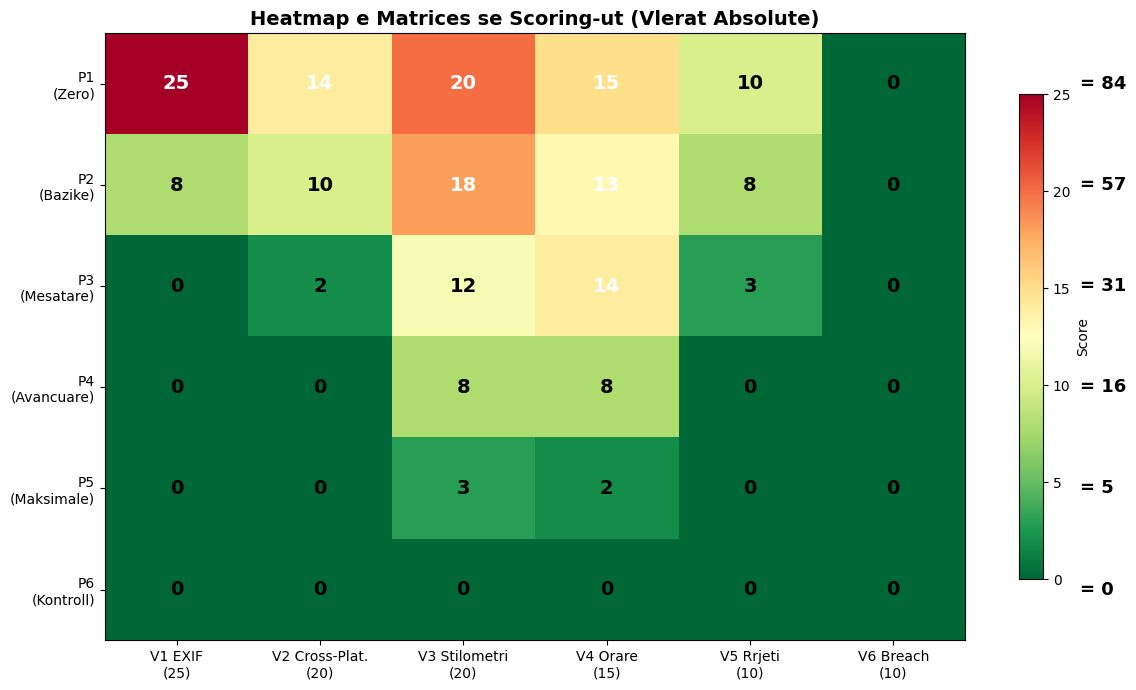

Heatmap i ruajtur


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

base = r"C:\Users\Laura Biba\Desktop\OSINT Research"

profiles = ['P1\n(Zero)', 'P2\n(Bazike)', 'P3\n(Mesatare)', 'P4\n(Avancuare)', 'P5\n(Maksimale)', 'P6\n(Kontroll)']
vektore = ['V1 EXIF\n(25)', 'V2 Cross-Plat.\n(20)', 'V3 Stilometri\n(20)', 'V4 Orare\n(15)', 'V5 Rrjeti\n(10)', 'V6 Breach\n(10)']

data = np.array([
    [25, 14, 20, 15, 10, 0],
    [8, 10, 18, 13, 8, 0],
    [0, 2, 12, 14, 3, 0],
    [0, 0, 8, 8, 0, 0],
    [0, 0, 3, 2, 0, 0],
    [0, 0, 0, 0, 0, 0],
])

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(data, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=25)

ax.set_xticks(range(6))
ax.set_xticklabels(vektore, fontsize=10)
ax.set_yticks(range(6))
ax.set_yticklabels(profiles, fontsize=10)

for i in range(6):
    for j in range(6):
        color = 'white' if data[i][j] > 12 else 'black'
        ax.text(j, i, str(data[i][j]), ha='center', va='center', fontsize=14, fontweight='bold', color=color)

totals = [84, 57, 31, 16, 5, 0]
for i, total in enumerate(totals):
    ax.text(6.3, i, f'= {total}', ha='left', va='center', fontsize=13, fontweight='bold')

ax.set_title('Heatmap e Matrices se Scoring-ut (Vlerat Absolute)', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='Score', shrink=0.8)

plt.tight_layout()
plt.savefig(os.path.join(base, 'figurat', 'scoring_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap i ruajtur")